##### -------------------------------------------------------------------------------------------

### GEN AI WE PROGRAM [ ML Fundamentals ]
### Day 02 HandsOn
#### Suyog Yadav ( 20546756 )

##### -------------------------------------------------------------------------------------------

### Assignment: Loan Defaulter Analysis & Prediction

a.  Analyse the credit score distribution using a histogram

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style('whitegrid')
np.random.seed(21)

In [16]:

df = pd.read_csv("loan_default_dataset.csv")
print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())

print('\nTarget distribution (Default):')
print(df['Default'].value_counts())

Dataset shape: (10000, 11)

Columns:
['Age', 'Annual_Income', 'Employment_Years', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Debt_To_Income_Ratio', 'Previous_Defaults', 'Dependents', 'Home_Owner', 'Default']

First 5 rows:
   Age  Annual_Income  Employment_Years  Credit_Score  Loan_Amount  \
0   59         491442                35           649       708905   
1   49         537347                14           841       313302   
2   35         988630                29           755       282415   
3   63         692788                14           513       502710   
4   28        1307120                22           670       766560   

   Loan_Term_Months  Debt_To_Income_Ratio  Previous_Defaults  Dependents  \
0                12                  0.60                  0           2   
1                48                  0.29                  0           1   
2                24                  0.33                  0           2   
3                24                  0.31  

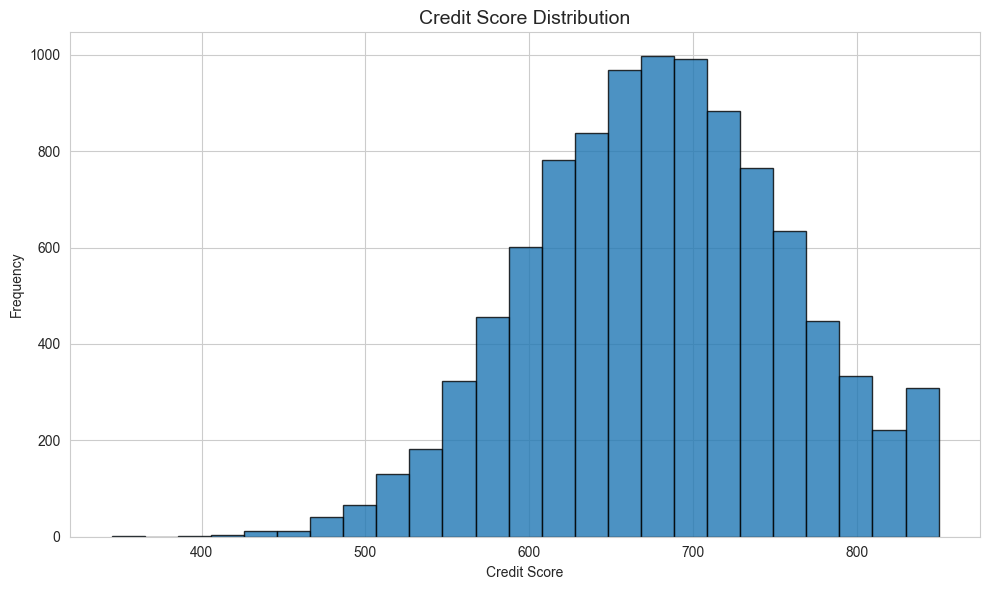

Histogram saved to: day2_credit_score_histogram.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['Credit_Score'], bins=25, color='#1f77b4', edgecolor='black', alpha=0.8)
ax.set_title('Credit Score Distribution', fontsize=14)
ax.set_xlabel('Credit Score')
ax.set_ylabel('Frequency')
plt.tight_layout()

hist_path = Path('day2_credit_score_histogram.png')
fig.savefig(hist_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Histogram saved to: {hist_path}')

b.  Analyse how credit scores differ between defaulters and non-
defaulters using a box plot 

/var/folders/gp/4dnnkdm55819tsnwhpp3hrn00000gp/T/ipykernel_58392/2658200364.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Default_Label', y='Credit_Score', palette=['#2ca02c', '#d62728'], ax=ax)


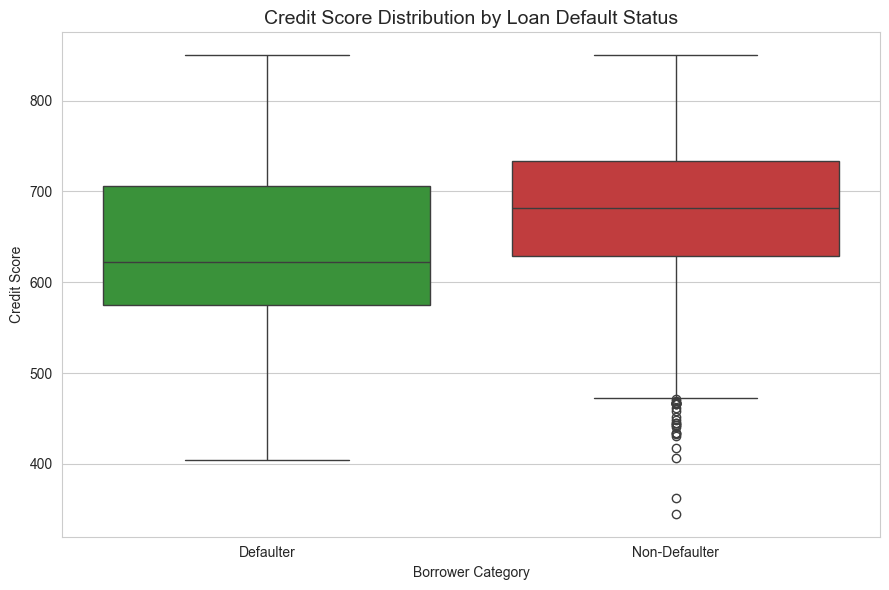

Box plot saved to: day2_credit_score_boxplot.png


In [18]:
plot_df = df.copy()
plot_df['Default_Label'] = plot_df['Default'].map({0: 'Non-Defaulter', 1: 'Defaulter'})

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=plot_df, x='Default_Label', y='Credit_Score', palette=['#2ca02c', '#d62728'], ax=ax)
ax.set_title('Credit Score Distribution by Loan Default Status', fontsize=14)
ax.set_xlabel('Borrower Category')
ax.set_ylabel('Credit Score')
plt.tight_layout()

boxplot_path = Path('day2_credit_score_boxplot.png')
fig.savefig(boxplot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Box plot saved to: {boxplot_path}')

c.  Predict whether a borrower is likely to default on a loan using Logistic 
Regression

In [19]:
target_col = 'Default'
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['Age', 'Annual_Income', 'Employment_Years', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Debt_To_Income_Ratio', 'Previous_Defaults', 'Dependents']
Categorical features: ['Home_Owner']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=21)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Model training completed.')
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Model training completed.
Train size: 8000, Test size: 2000


d.  Generate Confusion matrix

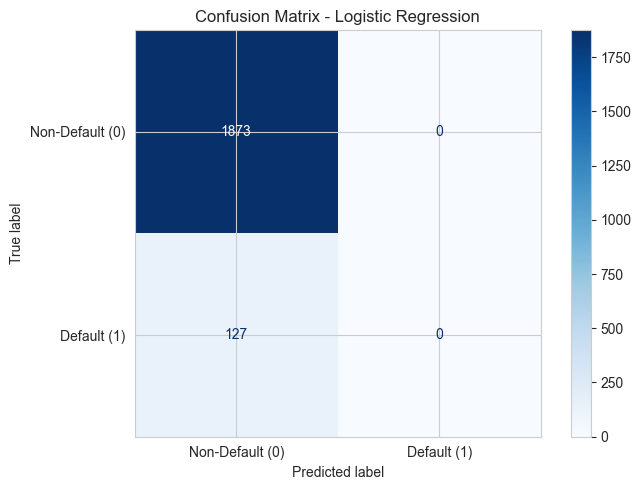

Confusion matrix image saved to: day2_confusion_matrix.png


In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default (0)', 'Default (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()

cm_path = Path('day2_confusion_matrix.png')
fig.savefig(cm_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Confusion matrix image saved to: {cm_path}')

e. Classification Report and Accuracy Score of the model

In [22]:
accuracy = accuracy_score(y_test, y_pred)
report_text = classification_report(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)

print('=' * 60)
print('MODEL PERFORMANCE')
print('=' * 60)
print(f'Accuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)')
print('\nClassification Report:')
print(report_text)

MODEL PERFORMANCE
Accuracy Score: 0.9370 (93.70%)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1873
           1       0.52      0.13      0.20       127

    accuracy                           0.94      2000
   macro avg       0.73      0.56      0.58      2000
weighted avg       0.92      0.94      0.92      2000



f. find the Precision, Recall & F1-
score of the model.

Detailed metrics table:
              precision    recall  f1-score   support
0              0.943626  0.991991  0.967205  1873.000
1              0.516129  0.125984  0.202532   127.000
accuracy       0.937000  0.937000  0.937000     0.937
macro avg      0.729878  0.558988  0.584868  2000.000
weighted avg   0.916480  0.937000  0.918648  2000.000


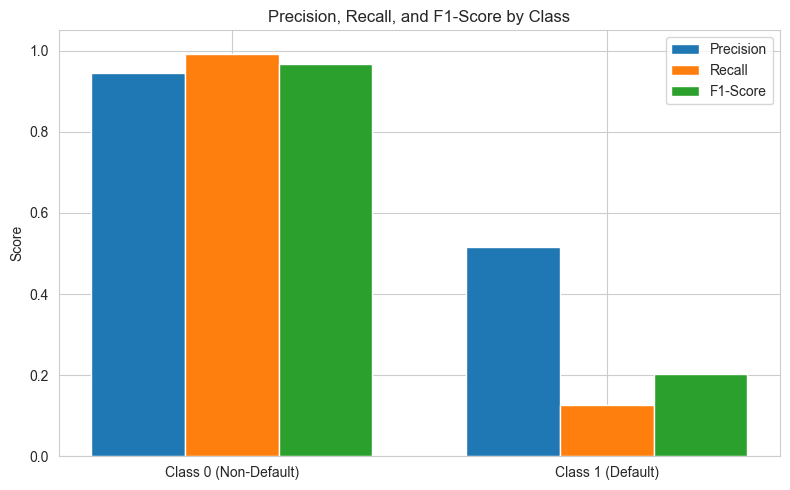

Metrics chart saved to: day2_prf1_scores.png


In [23]:
metrics_df = pd.DataFrame(report_dict).transpose()
print('Detailed metrics table:')
print(metrics_df)

fig, ax = plt.subplots(figsize=(8, 5))
summary_labels = ['0', '1']
precision_vals = [report_dict[label]['precision'] for label in summary_labels]
recall_vals = [report_dict[label]['recall'] for label in summary_labels]
f1_vals = [report_dict[label]['f1-score'] for label in summary_labels]

x = np.arange(len(summary_labels))
width = 0.25
ax.bar(x - width, precision_vals, width, label='Precision', color='#1f77b4')
ax.bar(x, recall_vals, width, label='Recall', color='#ff7f0e')
ax.bar(x + width, f1_vals, width, label='F1-Score', color='#2ca02c')

ax.set_xticks(x)
ax.set_xticklabels(['Class 0 (Non-Default)', 'Class 1 (Default)'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score by Class')
ax.legend()
plt.tight_layout()

metrics_plot_path = Path('day2_prf1_scores.png')
fig.savefig(metrics_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Metrics chart saved to: {metrics_plot_path}')